In [1]:
# This R environment comes with many helpful analytics packages installed
# It is defined by the kaggle/rstats Docker image: https://github.com/kaggle/docker-rstats
# For example, here's a helpful package to load

library(tidyverse) # metapackage of all tidyverse packages

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

list.files(path = "../input")

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


[1] "life-style-data"

In [2]:
df <- read.csv("/kaggle/input/life-style-data/Final_data.csv")
head(df)


,Age,Gender,Weight..kg.,Height..m.,Max_BPM,Avg_BPM,Resting_BPM,Session_Duration..hours.,Calories_Burned,Workout_Type,⋯,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns.Calories..per.30.min._bc,Burns_Calories_Bin
,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,34.91,Male,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,Strength,⋯,2139.59,0.5004323,1.6247893,0.7412365,0.8359847,725.10,47.77739,685.1600,7.260425e+19,Medium
2,23.37,Female,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,HIIT,⋯,1711.65,0.5008501,1.5140932,0.5512471,0.7342696,-232.91,40.80980,978.6184,1.020506e+20,High
3,33.20,Female,58.98,1.67,175.04,123.95,54.96,0.91,802.26,Cardio,⋯,1965.92,0.5006104,1.6634452,0.5745336,0.7081239,805.74,44.63558,654.5266,1.079607e+20,High
4,38.69,Female,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,HIIT,⋯,1627.28,0.4995330,0.8620175,0.7441547,0.8111500,1206.21,63.00743,773.6300,8.987921e+19,High
5,45.09,Male,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,Strength,⋯,2659.23,0.5005810,2.5381534,0.6684048,0.7897510,303.60,43.34750,711.4176,5.264685e+19,Low
6,53.19,Female,105.05,1.84,176.52,130.60,61.84,0.69,453.33,Yoga,⋯,1369.66,0.4989851,0.6465493,0.5995814,0.7398595,2313.67,71.38246,516.8928,1.505159e+20,Very High


In [3]:
colnames(df)

[1] "Age"                            "Gender"                        
 [3] "Weight..kg."                    "Height..m."                    
 [5] "Max_BPM"                        "Avg_BPM"                       
 [7] "Resting_BPM"                    "Session_Duration..hours."      
 [9] "Calories_Burned"                "Workout_Type"                  
[11] "Fat_Percentage"                 "Water_Intake..liters."         
[13] "Workout_Frequency..days.week."  "Experience_Level"              
[15] "BMI"                            "Daily.meals.frequency"         
[17] "Physical.exercise"              "Carbs"                         
[19] "Proteins"                       "Fats"                          
[21] "Calories"                       "meal_name"                     
[23] "meal_type"                      "diet_type"                     
[25] "sugar_g"                        "sodium_mg"                     
[27] "cholesterol_mg"                 "serving_size_g"                
[29] "cooking_method"                 "prep_time_min"                 
[31] "cook_time_min"                  "rating"                        
[33] "Name.of.Exercise"               "Sets"                          
[35] "Reps"                           "Benefit"                       
[37] "Burns.Calories..per.30.min."    "Target.Muscle.Group"           
[39] "Equipment.Needed"               "Difficulty.Level"              
[41] "Body.Part"                      "Type.of.Muscle"                
[43] "Workout"                        "BMI_calc"                      
[45] "cal_from_macros"                "pct_carbs"                     
[47] "protein_per_kg"                 "pct_HRR"                       
[49] "pct_maxHR"                      "cal_balance"                   
[51] "lean_mass_kg"                   "expected_burn"                 
[53] "Burns.Calories..per.30.min._bc" "Burns_Calories_Bin"

In [4]:
str(df)

'data.frame':	20000 obs. of  54 variables:
 $ Age                           : num  34.9 23.4 33.2 38.7 45.1 ...
 $ Gender                        : chr  "Male" "Female" "Female" "Female" ...
 $ Weight..kg.                   : num  65.3 56.4 59 93.8 52.4 ...
 $ Height..m.                    : num  1.62 1.55 1.67 1.7 1.88 1.84 1.78 1.63 1.79 1.6 ...
 $ Max_BPM                       : num  189 179 175 191 194 ...
 $ Avg_BPM                       : num  158 132 124 155 153 ...
 $ Resting_BPM                   : num  69 73.2 55 50.1 70.8 ...
 $ Session_Duration..hours.      : num  1 1.37 0.91 1.1 1.08 0.69 1.67 1.01 1.76 1.17 ...
 $ Calories_Burned               : num  1081 1810 802 1451 1166 ...
 $ Workout_Type                  : chr  "Strength" "HIIT" "Cardio" "HIIT" ...
 $ Fat_Percentage                : num  26.8 27.7 24.3 32.8 17.3 ...
 $ Water_Intake..liters.         : num  1.5 1.9 1.88 2.5 2.91 2.91 2.71 2.88 3.49 2.49 ...
 $ Workout_Frequency..days.week. : num  3.99 4 2.99 3.99 4 3.0

In [5]:
summary(df)

      Age           Gender           Weight..kg.       Height..m.   
 Min.   :18.00   Length:20000       Min.   : 39.18   Min.   :1.490  
 1st Qu.:28.17   Class :character   1st Qu.: 58.16   1st Qu.:1.620  
 Median :39.87   Mode  :character   Median : 70.00   Median :1.710  
 Mean   :38.85                      Mean   : 73.90   Mean   :1.723  
 3rd Qu.:49.63                      3rd Qu.: 86.10   3rd Qu.:1.800  
 Max.   :59.67                      Max.   :130.77   Max.   :2.010  
    Max_BPM         Avg_BPM       Resting_BPM    Session_Duration..hours.
 Min.   :159.3   Min.   :119.1   Min.   :49.49   Min.   :0.490           
 1st Qu.:170.1   1st Qu.:131.2   1st Qu.:55.96   1st Qu.:1.050           
 Median :180.1   Median :143.0   Median :62.20   Median :1.270           
 Mean   :179.9   Mean   :143.7   Mean   :62.20   Mean   :1.259           
 3rd Qu.:189.4   3rd Qu.:156.1   3rd Qu.:68.09   3rd Qu.:1.460           
 Max.   :199.6   Max.   :169.8   Max.   :74.50   Max.   :2.020           

In [6]:
summarise(df,avg_age=mean(Age,na.rm=TRUE), avg_bmi=mean(BMI,na.rm=TRUE))

avg_age,avg_bmi
<dbl>,<dbl>
38.85145,24.92168


In [7]:
table(df$Gender)


Female   Male 
 10028   9972 

In [8]:
table(df$Workout_Type)


  Cardio     HIIT Strength     Yoga 
    4923     4974     5071     5032 

In [9]:
n_distinct(df$Workout_Type)

[1] 4

In [10]:
n_distinct(df$diet_type)

[1] 6

In [11]:
unique(df$diet_type)

[1] "Vegan"      "Vegetarian" "Paleo"      "Keto"       "Low-Carb"  
[6] "Balanced"

In [12]:
dim(df)

[1] 20000    54

In [13]:
glimpse(df)

Rows: 20,000
Columns: 54
$ Age                            <dbl> 34.91, 23.37, 33.20, 38.69, 45.09, 53.1…
$ Gender                         <chr> "Male", "Female", "Female", "Female", "…
$ Weight..kg.                    <dbl> 65.27, 56.41, 58.98, 93.78, 52.42, 105.…
$ Height..m.                     <dbl> 1.62, 1.55, 1.67, 1.70, 1.88, 1.84, 1.7…
$ Max_BPM                        <dbl> 188.58, 179.43, 175.04, 191.21, 193.58,…
$ Avg_BPM                        <dbl> 157.65, 131.75, 123.95, 155.10, 152.88,…
$ Resting_BPM                    <dbl> 69.05, 73.18, 54.96, 50.07, 70.84, 61.8…
$ Session_Duration..hours.       <dbl> 1.00, 1.37, 0.91, 1.10, 1.08, 0.69, 1.6…
$ Calories_Burned                <dbl> 1080.90, 1809.91, 802.26, 1450.79, 1166…
$ Workout_Type                   <chr> "Strength", "HIIT", "Cardio", "HIIT", "…
$ Fat_Percentage                 <dbl> 26.80038, 27.65502, 24.32082, 32.81357,…
$ Water_Intake..liters.          <dbl> 1.50, 1.90, 1.88, 2.50, 2.91, 2.91, 2.7…
$ Workout_Frequ

In [14]:
df[1:5,c('Age','Gender','BMI')]

,Age,Gender,BMI
,<dbl>,<chr>,<dbl>
1,34.91,Male,24.87
2,23.37,Female,23.48
3,33.20,Female,21.15
4,38.69,Female,32.45
5,45.09,Male,14.83


In [15]:
df[1:5,c('Daily.meals.frequency','Physical.exercise')]

,Daily.meals.frequency,Physical.exercise
,<dbl>,<dbl>
1,2.99,0.01
2,3.01,0.97
3,1.99,-0.02
4,3.00,0.04
5,3.00,3.00


In [16]:
head(df$Workout_Type,10)

[1] "Strength" "HIIT"     "Cardio"   "HIIT"     "Strength" "Yoga"    
 [7] "Strength" "Yoga"     "Strength" "Strength"

In [17]:
unique(df$Workout_Type)

[1] "Strength" "HIIT"     "Cardio"   "Yoga"

In [18]:
df[1:5,c('Age','BMI')]

,Age,BMI
,<dbl>,<dbl>
1,34.91,24.87
2,23.37,23.48
3,33.20,21.15
4,38.69,32.45
5,45.09,14.83


In [19]:
n_distinct(subset(df,Gender=="Male"))

[1] 9972

In [20]:
head(subset(df,Gender=='Male'&Age > 40),10)

,Age,Gender,Weight..kg.,Height..m.,Max_BPM,Avg_BPM,Resting_BPM,Session_Duration..hours.,Calories_Burned,Workout_Type,⋯,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns.Calories..per.30.min._bc,Burns_Calories_Bin
,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
5,45.09,Male,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,Strength,⋯,2659.23,0.5005810,2.538153,0.6684048,0.7897510,303.60,43.34750,711.4176,5.264685e+19,Low
11,50.51,Male,86.37,1.63,160.92,143.20,57.87,1.69,1974.26,Strength,⋯,2065.28,0.5015882,1.189302,0.8280446,0.8898832,501.74,61.26092,1203.9560,9.983135e+19,High
17,40.36,Male,56.88,1.71,168.02,142.67,60.89,1.87,2189.58,Strength,⋯,1538.55,0.5008872,1.350211,0.7633716,0.8491251,-449.58,44.47489,1280.8378,7.241406e+19,Medium
20,46.00,Male,60.05,1.68,164.91,147.10,62.34,1.17,1544.40,HIIT,⋯,1985.60,0.4995165,1.655287,0.8263625,0.8920017,171.60,46.95668,819.5382,8.695711e+19,High
25,50.53,Male,57.01,1.91,184.12,131.58,68.07,1.09,1177.20,Strength,⋯,1421.78,0.5006963,1.246273,0.5472641,0.7146426,332.80,44.24398,784.8872,1.089703e+20,High
32,49.66,Male,52.57,1.84,195.03,124.28,51.70,1.38,1324.80,Cardio,⋯,1361.81,0.4978668,1.301503,0.5063839,0.6372353,172.20,44.76757,955.8156,7.931882e+19,Medium
34,41.80,Male,59.72,1.74,194.24,141.17,51.86,1.78,2545.40,HIIT,⋯,1609.46,0.5034484,1.340422,0.6272651,0.7267813,-804.40,48.10643,1299.2220,1.217206e+20,Very High
41,40.14,Male,51.72,1.61,198.12,128.23,70.18,0.86,566.57,Yoga,⋯,1731.82,0.5022693,1.677301,0.4537283,0.6472340,758.43,39.45556,618.1680,1.073980e+20,High
49,40.09,Male,54.73,1.61,183.75,157.78,64.12,1.55,1209.00,Yoga,⋯,2196.71,0.4996381,2.005299,0.7829140,0.8586667,340.00,42.35568,1033.2610,5.803061e+19,Low


In [21]:
library(dplyr)



In [22]:
df %>%
filter(Gender=='Male',Age>40) %>%
select(Gender,Age) %>%
head()

,Gender,Age
,<chr>,<dbl>
1,Male,45.09
2,Male,50.51
3,Male,40.36
4,Male,46.00
5,Male,50.53
6,Male,49.66


In [23]:
df %>%
filter(Calories_Burned > 500) %>%
select(Age,Gender,Calories_Burned) %>%
head()

,Age,Gender,Calories_Burned
,<dbl>,<chr>,<dbl>
1,34.91,Male,1080.90
2,23.37,Female,1809.91
3,33.20,Female,802.26
4,38.69,Female,1450.79
5,45.09,Male,1166.40
6,23.17,Male,1953.90


In [24]:
df %>%
filter(Calories_Burned > 500) %>%
count(Gender)

Gender,n
<chr>,<int>
Female,9735
Male,9670


In [25]:
head(subset(df,Workout_Frequency..days.week.>3 & Gender=='Male'& Age>35))

,Age,Gender,Weight..kg.,Height..m.,Max_BPM,Avg_BPM,Resting_BPM,Session_Duration..hours.,Calories_Burned,Workout_Type,⋯,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns.Calories..per.30.min._bc,Burns_Calories_Bin
,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
5,45.09,Male,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,Strength,⋯,2659.23,0.5005810,2.538153,0.6684048,0.7897510,303.60,43.34750,711.4176,5.264685e+19,Low
11,50.51,Male,86.37,1.63,160.92,143.20,57.87,1.69,1974.26,Strength,⋯,2065.28,0.5015882,1.189302,0.8280446,0.8898832,501.74,61.26092,1203.9560,9.983135e+19,High
17,40.36,Male,56.88,1.71,168.02,142.67,60.89,1.87,2189.58,Strength,⋯,1538.55,0.5008872,1.350211,0.7633716,0.8491251,-449.58,44.47489,1280.8378,7.241406e+19,Medium
18,37.14,Male,76.48,1.77,180.29,127.80,56.76,1.36,1305.60,Cardio,⋯,1868.13,0.5002221,1.215873,0.5750830,0.7088580,860.40,53.30600,970.9856,1.016312e+20,High
20,46.00,Male,60.05,1.68,164.91,147.10,62.34,1.17,1544.40,HIIT,⋯,1985.60,0.4995165,1.655287,0.8263625,0.8920017,171.60,46.95668,819.5382,8.695711e+19,High
25,50.53,Male,57.01,1.91,184.12,131.58,68.07,1.09,1177.20,Strength,⋯,1421.78,0.5006963,1.246273,0.5472641,0.7146426,332.80,44.24398,784.8872,1.089703e+20,High


In [26]:
df %>%
filter(Experience_Level %in% c(1,2,3)) %>%
head()

,Age,Gender,Weight..kg.,Height..m.,Max_BPM,Avg_BPM,Resting_BPM,Session_Duration..hours.,Calories_Burned,Workout_Type,⋯,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns.Calories..per.30.min._bc,Burns_Calories_Bin
,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,45.09,Male,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,Strength,⋯,2659.23,0.5005810,2.5381534,0.6684048,0.7897510,303.60,43.34750,711.4176,5.264685e+19,Low
2,53.19,Female,105.05,1.84,176.52,130.60,61.84,0.69,453.33,Yoga,⋯,1369.66,0.4989851,0.6465493,0.5995814,0.7398595,2313.67,71.38246,516.8928,1.505159e+20,Very High
3,23.17,Male,58.41,1.78,184.75,140.90,58.01,1.67,1953.90,Strength,⋯,2245.45,0.4993743,1.9234720,0.6540161,0.7626522,-86.90,46.40891,1098.6596,5.210106e+19,Low
4,39.19,Female,50.32,1.60,166.88,128.04,49.91,1.17,1157.25,Strength,⋯,1527.67,0.5002651,1.5254372,0.6679490,0.7672579,89.75,39.29520,763.5654,4.879494e+19,Low
5,38.01,Female,57.67,1.56,184.91,132.43,54.04,1.64,2345.20,HIIT,⋯,2955.34,0.5003959,2.5623374,0.5989914,0.7161863,-619.20,42.33299,1110.4112,6.589948e+19,Medium
6,37.14,Male,76.48,1.77,180.29,127.80,56.76,1.36,1305.60,Cardio,⋯,1868.13,0.5002221,1.2158734,0.5750830,0.7088580,860.40,53.30600,970.9856,1.016312e+20,High


In [27]:
df %>%
group_by(Gender) %>%
summarise(
    avg_bmi=mean(BMI, na.rm=TRUE),
    avg_cb=mean(Calories_Burned, na.rm=TRUE)
)

Gender,avg_bmi,avg_cb
<chr>,<dbl>,<dbl>
Female,24.85067,1279.585
Male,24.99309,1280.637


In [28]:
df %>%
mutate(
    Experience_Group=case_when(
        Experience_Level >= 5 ~ "Senior",
        Experience_Level >= 3 & Experience_Level <=4 ~ 'Mid',
        Experience_Level >= 1 & Experience_Level <= 2 ~ 'Junior',
        TRUE ~ 'Others'    
    )
)%>%
select(Gender, Experience_Group) %>%
head()

,Gender,Experience_Group
,<chr>,<chr>
1,Male,Others
2,Female,Others
3,Female,Junior
4,Female,Junior
5,Male,Junior
6,Female,Junior


In [29]:
df %>%
arrange(desc(Calories_Burned)) %>%
head()

,Age,Gender,Weight..kg.,Height..m.,Max_BPM,Avg_BPM,Resting_BPM,Session_Duration..hours.,Calories_Burned,Workout_Type,⋯,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns.Calories..per.30.min._bc,Burns_Calories_Bin
,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,47.41,Female,87.41,1.64,177.14,164.64,49.85,2.02,2890.82,HIIT,⋯,1851.64,0.4996220,1.0653243,0.9017990,0.9294343,-538.82,58.58856,1394.648,7.728420e+19,Medium
2,46.95,Male,87.21,1.64,177.59,164.65,50.05,2.01,2876.51,HIIT,⋯,1858.80,0.5026038,1.0621488,0.8985416,0.9271355,-497.51,60.24714,1386.980,7.693745e+19,Medium
3,41.05,Female,62.00,1.79,180.92,161.97,73.02,2.00,2864.40,HIIT,⋯,1235.01,0.4985547,0.9958065,0.8243744,0.8952576,-965.40,47.61251,1390.320,8.172624e+19,Medium
4,41.19,Male,62.33,1.79,180.96,161.85,72.92,2.00,2862.20,HIIT,⋯,1245.99,0.5004214,1.0011231,0.8231211,0.8943966,-1057.20,49.15620,1392.560,8.280800e+19,Medium
5,59.14,Female,85.97,1.67,190.36,144.10,70.90,2.00,2860.00,HIIT,⋯,1718.95,0.4979319,1.0034896,0.6127574,0.7569868,-406.00,58.82890,1467.880,1.273349e+20,Very High
6,41.07,Male,62.77,1.79,180.80,162.43,72.89,2.00,2860.00,HIIT,⋯,1248.24,0.5011857,0.9858213,0.8297655,0.8983960,-968.00,49.89351,1393.000,8.302196e+19,Medium


In [30]:
df %>%
select(Age, Gender, BMI,Calories_Burned) %>%
head()

,Age,Gender,BMI,Calories_Burned
,<dbl>,<chr>,<dbl>,<dbl>
1,34.91,Male,24.87,1080.90
2,23.37,Female,23.48,1809.91
3,33.20,Female,21.15,802.26
4,38.69,Female,32.45,1450.79
5,45.09,Male,14.83,1166.40
6,53.19,Female,31.03,453.33


In [31]:
df %>%
filter(Gender=='Male' & Age>=25 & Age<=35) %>%
head()

,Age,Gender,Weight..kg.,Height..m.,Max_BPM,Avg_BPM,Resting_BPM,Session_Duration..hours.,Calories_Burned,Workout_Type,⋯,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns.Calories..per.30.min._bc,Burns_Calories_Bin
,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,34.91,Male,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,Strength,⋯,2139.59,0.5004323,1.6247893,0.7412365,0.8359847,725.10,47.77739,685.1600,7.260425e+19,Medium
2,31.63,Male,126.53,1.83,197.68,146.15,61.92,1.10,790.68,Yoga,⋯,2443.91,0.4988727,0.9703628,0.6204331,0.7393262,2464.32,82.24450,794.6400,1.118717e+20,Very High
3,27.19,Male,88.20,1.98,161.80,152.85,52.99,1.80,2577.96,HIIT,⋯,2371.53,0.5000485,1.3400227,0.9177465,0.9446848,-46.96,69.63648,1211.5800,6.280149e+19,Low
4,33.07,Male,102.83,1.75,185.94,140.25,52.91,1.40,1003.80,Yoga,⋯,2306.15,0.5006613,1.1202956,0.6565436,0.7542756,1653.20,72.04941,1018.5840,1.185691e+20,Very High
5,32.59,Male,52.75,1.66,190.86,128.92,71.91,1.26,1248.53,Strength,⋯,1976.68,0.5000101,1.8619905,0.4792770,0.6754689,197.47,40.31916,882.9072,8.722111e+19,High
6,29.01,Male,58.43,1.61,197.67,121.65,72.05,1.20,1296.00,Strength,⋯,1756.88,0.5009335,1.4964915,0.3948416,0.6154196,475.00,42.33490,841.8240,8.803785e+19,High


In [32]:
colnames(df)

[1] "Age"                            "Gender"                        
 [3] "Weight..kg."                    "Height..m."                    
 [5] "Max_BPM"                        "Avg_BPM"                       
 [7] "Resting_BPM"                    "Session_Duration..hours."      
 [9] "Calories_Burned"                "Workout_Type"                  
[11] "Fat_Percentage"                 "Water_Intake..liters."         
[13] "Workout_Frequency..days.week."  "Experience_Level"              
[15] "BMI"                            "Daily.meals.frequency"         
[17] "Physical.exercise"              "Carbs"                         
[19] "Proteins"                       "Fats"                          
[21] "Calories"                       "meal_name"                     
[23] "meal_type"                      "diet_type"                     
[25] "sugar_g"                        "sodium_mg"                     
[27] "cholesterol_mg"                 "serving_size_g"                
[29] "cooking_method"                 "prep_time_min"                 
[31] "cook_time_min"                  "rating"                        
[33] "Name.of.Exercise"               "Sets"                          
[35] "Reps"                           "Benefit"                       
[37] "Burns.Calories..per.30.min."    "Target.Muscle.Group"           
[39] "Equipment.Needed"               "Difficulty.Level"              
[41] "Body.Part"                      "Type.of.Muscle"                
[43] "Workout"                        "BMI_calc"                      
[45] "cal_from_macros"                "pct_carbs"                     
[47] "protein_per_kg"                 "pct_HRR"                       
[49] "pct_maxHR"                      "cal_balance"                   
[51] "lean_mass_kg"                   "expected_burn"                 
[53] "Burns.Calories..per.30.min._bc" "Burns_Calories_Bin"

In [33]:
ggplot(df,aes(x=BMI_Status, y=avg_calories))+geom_col(position="dodge")

ERROR while rich displaying an object: Error in `geom_col()`:
! Problem while computing aesthetics.
ℹ Error occurred in the 1st layer.
Caused by error:
! object 'BMI_Status' not found

Traceback:
1. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
2. tryCatchList(expr, classes, parentenv, handlers)
3. tryCatchOne(expr, names, parentenv, handlers[[1L]])
4. doTryCatch(return(expr), name, parentenv, handler)
5. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handl

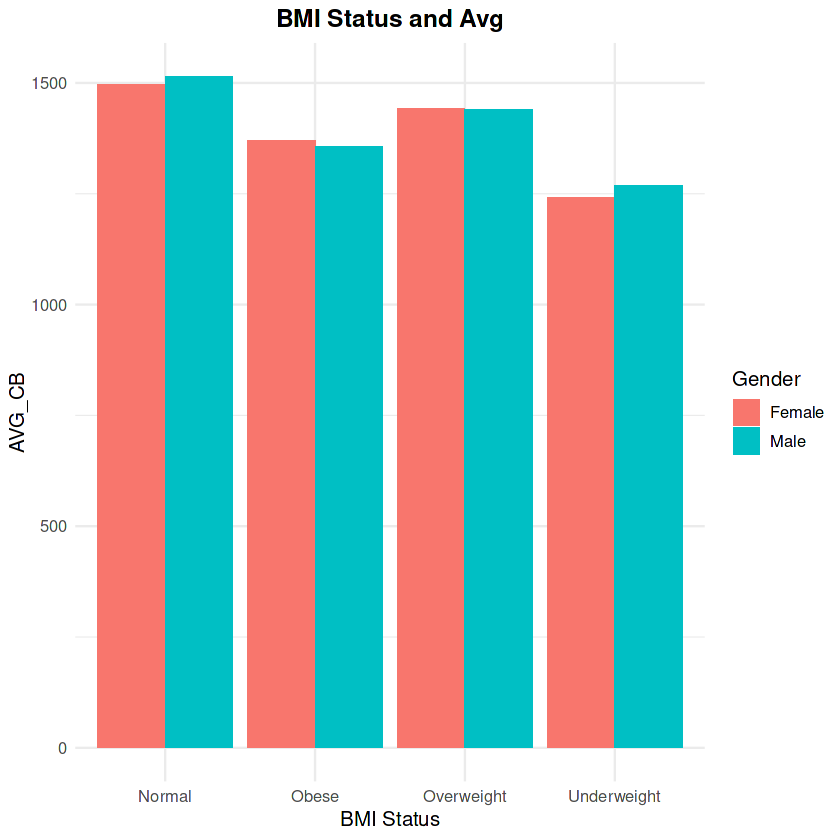

In [34]:
calorie_summary <-df %>%
filter(Workout_Frequency..days.week. >= 3,Calories_Burned >= 400) %>%
select(Gender, Age, BMI, Workout_Type, Calories_Burned, Experience_Level) %>%
mutate(
    BMI_Status = case_when(
      BMI >= 30 ~ "Obese",
      BMI >= 25 & BMI < 30 ~ "Overweight",
      BMI >= 18.5 & BMI < 25 ~ "Normal",
      BMI < 18.5 ~ "Underweight",
      TRUE ~ "Unknown"
    )
)%>%
arrange(desc(Calories_Burned),Age)%>%
group_by(Gender, BMI_Status) %>% 
summarise(
    avg_bmi=mean(BMI, na.rm=TRUE),
    avg_cb=mean(Calories_Burned, na.rm=TRUE),
    count=n(),
    .groups = "drop"
)
ggplot(calorie_summary ,aes(x=BMI_Status, y=avg_cb, fill=Gender))+
geom_col(position="dodge")+
labs(title=" BMI Status and Avg ",
    x="BMI Status",
    y="AVG_CB") +
  theme_minimal() +
  theme(
    text = element_text(size = 12),
    plot.title = element_text(face = "bold", hjust = 0.5)
  )

In [35]:
df %>%
group_by (Gender) %>%
summarise (
    avg_bmi=mean(BMI, na.rm=TRUE),
    avg_gb=mean(Calories_Burned, na.rm=TRUE),
    avg_eb= mean(expected_burn,  na.rm=TRUE)
    
)

Gender,avg_bmi,avg_gb,avg_eb
<chr>,<dbl>,<dbl>,<dbl>
Female,24.85067,1279.585,865.9915
Male,24.99309,1280.637,866.7152


In [36]:
df %>%
arrange(desc(BMI)) %>%
select(Gender,Age,BMI) %>%
head()
        

,Gender,Age,BMI
,<chr>,<dbl>,<dbl>
1,Female,47.79,50.23
2,Female,48.12,50.17
3,Male,48.26,50.08
4,Female,48.08,50.05
5,Male,48.19,49.97
6,Male,47.62,49.94


In [37]:
df %>%
select(Gender,Age) %>%
head()

,Gender,Age
,<chr>,<dbl>
1,Male,34.91
2,Female,23.37
3,Female,33.20
4,Female,38.69
5,Male,45.09
6,Female,53.19


In [38]:
df %>%
filter(Gender=='Female'& BMI>18 & BMI<25 ) %>%

head()

,Age,Gender,Weight..kg.,Height..m.,Max_BPM,Avg_BPM,Resting_BPM,Session_Duration..hours.,Calories_Burned,Workout_Type,⋯,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns.Calories..per.30.min._bc,Burns_Calories_Bin
,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,23.37,Female,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,HIIT,⋯,1711.65,0.5008501,1.514093,0.5512471,0.7342696,-232.91,40.80980,978.6184,1.020506e+20,High
2,33.20,Female,58.98,1.67,175.04,123.95,54.96,0.91,802.26,Cardio,⋯,1965.92,0.5006104,1.663445,0.5745336,0.7081239,805.74,44.63558,654.5266,1.079607e+20,High
3,39.19,Female,50.32,1.60,166.88,128.04,49.91,1.17,1157.25,Strength,⋯,1527.67,0.5002651,1.525437,0.6679490,0.7672579,89.75,39.29520,763.5654,4.879494e+19,Low
4,38.01,Female,57.67,1.56,184.91,132.43,54.04,1.64,2345.20,HIIT,⋯,2955.34,0.5003959,2.562337,0.5989914,0.7161863,-619.20,42.33299,1110.4112,6.589948e+19,Medium
5,27.39,Female,71.79,1.97,180.96,151.11,72.68,0.75,743.85,Strength,⋯,1654.72,0.5007735,1.150439,0.7243258,0.8350464,1302.15,54.21741,535.2450,1.012829e+20,High
6,37.06,Female,73.04,1.74,188.15,140.95,65.11,1.04,1123.20,Strength,⋯,2405.70,0.4993141,1.651561,0.6163849,0.7491363,914.80,54.20633,694.0336,5.854449e+19,Low


In [39]:
df %>%
group_by(Gender)%>%
summarise(mean(BMI))


Gender,mean(BMI)
<chr>,<dbl>
Female,24.85067
Male,24.99309


In [40]:
df %>%
count (Gender,Burns_Calories_Bin) %>%
arrange(n)


Gender,Burns_Calories_Bin,n
<chr>,<chr>,<int>
Male,Medium,2465
Female,Very High,2490
Male,Low,2492
Female,High,2495
Male,High,2505
Male,Very High,2510
Female,Low,2511
Female,Medium,2532


In [41]:
top_females <- df %>%
  filter(Gender == "Female", BMI >= 18, BMI < 25) %>%
  arrange(desc(Calories_Burned)) %>%
  head(5)

summary_stats <- df %>%
  filter(Gender == "Female", BMI >= 18, BMI < 25) %>%
  summarise(
    avg_calories = mean(Calories_Burned),
    max_calories = max(Calories_Burned)
  )

top_females
summary_stats

,Age,Gender,Weight..kg.,Height..m.,Max_BPM,Avg_BPM,Resting_BPM,Session_Duration..hours.,Calories_Burned,Workout_Type,⋯,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns.Calories..per.30.min._bc,Burns_Calories_Bin
,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,41.05,Female,62.00,1.79,180.92,161.97,73.02,2.00,2864.4,HIIT,⋯,1235.01,0.4985547,0.9958065,0.8243744,0.8952576,-965.4,47.61251,1390.320,8.172624e+19,Medium
2,46.50,Female,86.40,1.99,182.19,152.95,69.82,2.00,2855.6,HIIT,⋯,3209.15,0.4987863,1.8648148,0.7397882,0.8395082,-518.6,66.21833,1473.200,1.311545e+20,Very High
3,48.90,Female,81.87,1.83,167.02,125.33,72.89,1.99,2845.7,HIIT,⋯,1483.37,0.5036100,0.9059485,0.5571019,0.7503892,-475.7,62.82975,1421.218,1.018873e+20,High
4,40.35,Female,61.71,1.79,181.15,161.88,72.66,1.99,2845.7,HIIT,⋯,1248.62,0.4997197,1.0072922,0.8223799,0.8936241,-1111.7,49.80119,1385.637,8.282743e+19,Medium
5,20.81,Female,60.18,1.70,178.63,123.20,51.93,1.99,2845.7,HIIT,⋯,3130.07,0.4990687,2.6031904,0.5625099,0.6896938,-994.7,44.58930,1465.317,1.307767e+20,Very High


avg_calories,max_calories
<dbl>,<dbl>
1329.93,2864.4


In [42]:
df %>%
filter(Gender=='Female'& BMI >=18 & BMI<25) %>%
select(Age,Gender,BMI,Calories_Burned) %>%
arrange(Age,desc(Calories_Burned)) %>%
summary() %>%
head(10)

      Age           Gender               BMI        Calories_Burned 
 Min.   :18.00   Length:4106        Min.   :18.00   Min.   : 323.1  
 1st Qu.:28.21   Class :character   1st Qu.:20.00   1st Qu.: 935.2  
 Median :38.85   Mode  :character   Median :21.98   Median :1274.4  
 Mean   :38.00                      Mean   :21.76   Mean   :1329.9  
 3rd Qu.:47.26                      3rd Qu.:23.57   3rd Qu.:1618.3  
 Max.   :59.42                      Max.   :24.99   Max.   :2864.4  

In [43]:
number<-count(subset(df,Gender=='Male' & Age>20 & Age<30))
number

n
<int>
2170


In [44]:
df %>%
filter('Age'>50) %>%
select(Age,Gender) %>%
head()

,Age,Gender
,<dbl>,<chr>
1,34.91,Male
2,23.37,Female
3,33.20,Female
4,38.69,Female
5,45.09,Male
6,53.19,Female


In [45]:
df[,c('Age','Gender')]

Age,Gender
<dbl>,<chr>
34.91,Male
23.37,Female
33.20,Female
38.69,Female
45.09,Male
53.19,Female
23.17,Male
55.92,Female
24.11,Female


In [46]:
unique(df$Experience_Level)

[1] 2.01 1.02 1.99 2.00 1.00 3.00 3.02 2.98 3.01 2.99 1.98 1.95 2.02 2.97 1.97
[16] 1.01 3.03 2.04 1.04 2.96 3.04 1.03 1.94 2.03 1.96 2.95 3.05 2.05 1.05 2.06
[31] 1.06 2.94

In [47]:
c(Mean_age=mean(df$Age), Max_age=max(df$Age), Min_age=min(df$Age))

Mean_age  Max_age  Min_age 
38.85145 59.67000 18.00000